# PMP Example

Loads a PMP configuration from a LAMMPS frame to showcase the cavity sizing operation.

In [1]:
import vacuumms as v
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import Image
import numpy as np

## Cavity Size Distribution
#### Generate cavities

In [2]:
gfg=v.LAMMPSConfiguration("PMP.lmps")  # Load configuration from file 
ddx = v.DDX(gfg)                       # create the DDX (cavity-search) operation
ddx.setNumberOfSamples(10000)          # Generate 10000 cavity samples
ddx.setNumberOfSteps(50)               # Maximum number of steps before giving up and accepting result without explicit convergence
ddx.setLearningRate(0.01)              # Default is 0.01, sets learning rate for gradient descent of location of center
ddx.setTolerance(10.0)                 # 10.0 is default, comparison value to derivative to determine conversion
ddx.setRNGSeed(555)                    # Set random number generator seed
ddx.setVerletCutoff(64.0)              # default is 10.0 * 10.0 = 100.0, cutoff radius^2 when building Verlet list
ddx.setVerletExtent(2)                 # how many levels of mirror boxes to search when building Verlet list, default is 1
ddx.execute()                          # Execute the cavity sizing operation 

#### Generate the distribution

In [3]:
cavs=ddx.getResult()                  # Retrieve the cavity result from the ddx operation
cavs.scrubDuplicates()                # Remove duplicate cavities
csd = v.CavitySizeDistribution(cavs)  # Create the distribution container object
csd.setBinWidth(0.1)                  # Width of bins
csd.setNumberOfBins(50)               # Number of bins for sorting
csd.setStartingValue(0.4)             # Starting bin size
csd.generate()                        # Generate the distribution
csd.applyWeightExponent(3)            # For a volume-weighted distribution
csd.smooth(3)                         # Apply smoothing 3 times
csd                                   # Display the ASCII rendered result

0.400000:	
0.500000:	*
0.600000:	****
0.700000:	***********
0.800000:	***************************
0.900000:	****************************************************
1.000000:	********************************************************************************
1.100000:	**************************************************************************************************
1.200000:	***************************************************************************************************
1.300000:	****************************************************************************************
1.400000:	**************************************************************************
1.500000:	*****************************************************************
1.600000:	***************************************************************
1.700000:	*****************************************************************
1.800000:	********************************************************************
1.900000:	******************************

## Variational calculation
#### Select two large cavities to generate a variational trajectory

In [5]:
# Get the indices of the two largest values
# diameters = np.array(cavs.getDiameters())
# indices = np.argpartition(diameters, -2)[-2:]  # Get indices of top 2
# These are two of the largest, with a good separation for viewing

start = cavs.recordAt(131).getXYZ()
end = cavs.recordAt(254).getXYZ()

var=v.Variational3D(start, end, 1, 1, 100, gfg)  # Use 100 variational points
var.setDeltaMax(0.025)                           # Maximum nudge size per point per iteration
var.setAlpha(1.0)                                # Starting value of ADAM parameter for gradient descent
var.setAlphaMax(10)                              # Maximum allowed value
var.setVerbose(0)                                # Set verbose level to zero to limit output, higher for debugging and tuning

#### Iterate over the trajectory

In [6]:
array1 = np.array(var.getPoints(), dtype=np.float32)           # record the initial values of the variational curve
for _ in range(1000):                                          # Perform 1000 iterations
    shrinkage = var.adaptiveIterateAndUpdate()                 # Iterate and update the curve
    if ( _ % 100 == 0):                                        # Every 100 iterations, generate output
        array2 = np.array(var.getPoints(), dtype=np.float32)   # Record current positions of the variational curve
        distances = np.linalg.norm(array2 - array1, axis=1)    # Compare current positions to initial values
        sum=np.sum(distances)                                  # Sum the displacements of each of the variational points
        print("Cumulative distance nudged: ", _, sum)          # Report cumulative distance nudged, which will increase asymptotically

Cumulative distance nudged:  0 0.24791083
Cumulative distance nudged:  100 17.79297
Cumulative distance nudged:  200 24.495806
Cumulative distance nudged:  300 28.491753
Cumulative distance nudged:  400 31.178083
Cumulative distance nudged:  500 33.165207
Cumulative distance nudged:  600 34.74334
Cumulative distance nudged:  700 36.04268
Cumulative distance nudged:  800 37.140392
Cumulative distance nudged:  900 38.08291


#### Generate scene object to render result

In [7]:
scene = v.Scene()                    # Scene object

vc = v.VariationalComponent(var)     # Variational curve scene component
vc.setDiameter(0.1)                  # Diameter of trajectory when displayed
scene.addSceneComponent(vc)          # Add to the scene

cav2=v.CavityConfiguration()         # Create a configuration for just the endpoint cavities
cav2.pushBack(cavs.recordAt(131))  
cav2.pushBack(cavs.recordAt(254))
cav_scene2=v.CavityComponent(cav2)   # Create a scene component for the endpoint cavities
cav_scene2.setPhong(0.7)             # make it shiny
cav_scene2.setTransmit(0.0)          # make it opaque
cav_scene2.setColor("Yellow")        # make it Yellow
scene.addSceneComponent(cav_scene2)  # Add it to the scene

cav_scene=v.CavityComponent(cavs)    # Create a scene component for rest of the cavities
cav_scene.setPhong(0.3)              # make it shiny
cav_scene.setTransmit(0.99)          # make it nearly transparent
cav_scene.setColor("White")          # make it White
scene.addSceneComponent(cav_scene)   # Add it to the scene

In [8]:
#### Tune the rendering parameters

In [9]:
scene.setCameraLocation([44,33,66])
_end = np.array(end, dtype=np.float32)
_start = np.array(start, dtype=np.float32)
scene.setCameraLookAt((_end + _start)/2)
scene.setRenderDimensions(960,540)
scene.clearLightSources()
scene.addLightSource([1000,2000,3000],"White")
scene.applyAmbientLight()

# Scale the displayed ojbects for better visibility
cav_scene.rescale(0.7)
cav_scene2.rescale(0.7)

#### Render the scene

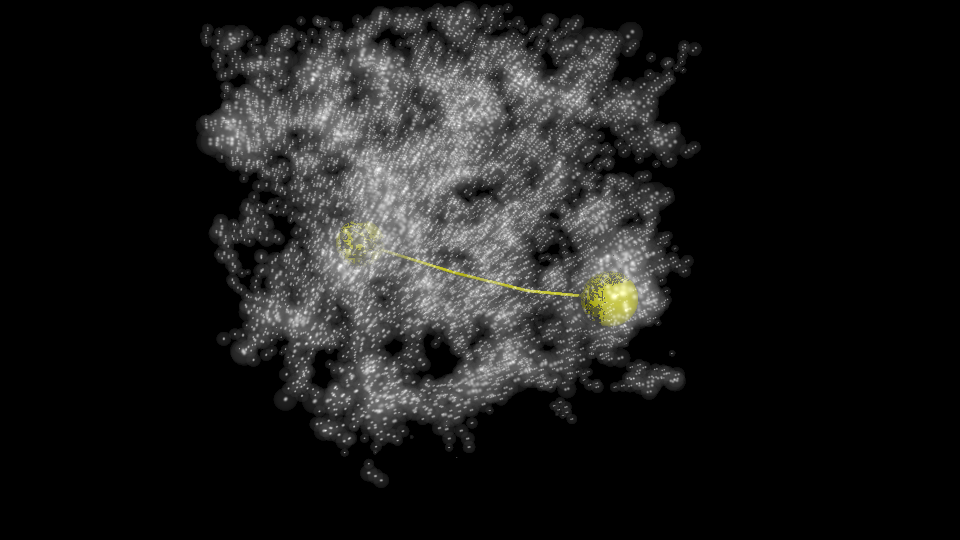

POV-Ray render completed successfully.
POV-Ray temporary file deleted successfully.


In [10]:
scene.renderScene("PMP-V.png")
Image(filename='PMP-V.png')